In [2]:
from deep_kolmogorov import modeling, pdes, trainer
import torch

# import importlib
# importlib.reload(modeling)

In [12]:
def get_option_price_curve_d_10(model, K, num_path, config):
    device = torch.device("cuda")
    with torch.no_grad(): 
        data = {
            key: torch.tensor((K+1)*num_path * [value], dtype=torch.float32, device=device) for key, value in config.items()
        }
        data.update(
            {
                "t": torch.linspace(model.pde.hypercubes["t"].interval[0], model.pde.hypercubes["t"].interval[1], K + 1, dtype=torch.float32, device=device).repeat(num_path).reshape(-1,1)
            }
        )
        batch = {
            key:torch.tensor(num_path * [value], dtype=torch.float32, device=device) for key, value in config.items()
        }
        x = torch.full((num_path,len(config["s"]),K+1), 1, dtype=torch.float32, device=device)
        for i in range(K+1):
            x[:, :, i] = batch["s"].clone()
            # dw = (1/K)** 0.5  * torch.randn(
            #     batch["s"].shape, dtype=batch["s"].dtype, device=batch["s"].device
            # )
            # batch["s"] = batch["s"] * torch.exp(
            #     batch["r"] * 1/K - 0.5 * 1/K * batch["sigma"] ** 2 + batch["sigma"] * dw
            # )
            n = len(config["s"])
            RHO = batch["rho"].view(num_path, 1, 1).expand(num_path, n, n).clone()
            RHO.as_strided((num_path, n), (n ** 2, n + 1)).fill_(1)
            sqrt_cov = torch.linalg.cholesky(RHO)

            dw = (1/K)**0.5 * torch.matmul(sqrt_cov, 
                                                    torch.randn(batch["s"].shape, dtype=batch["s"].dtype, device=batch["s"].device).unsqueeze(2)
            ).squeeze(2)
            batch["s"] = batch["s"] * torch.exp(
                batch["r"] * 1/K - 0.5 * 1/K * batch["sigma"] ** 2 + batch["sigma"] * dw
            )

        data["x"] = x.transpose(1,2).reshape(-1,len(config["s"]))
        if model.pde.get_K is not None:
            data["K"] = model.pde.get_K(data)
        tensor = model.pde.normalize_and_flatten(data)
        y_pred = model.net.forward(tensor)
        y_true = model.pde.solution(data)
    return {
        "t": data["t"].reshape(num_path, K+1),
        "y_pred": y_pred.reshape(num_path, K+1),
        "y_true": y_true.reshape(num_path, K+1)
        }


In [4]:
import matplotlib.pyplot as plt

def plot_mc_curves(t_test, y_pred, y_true=None):
    if t_test.device != "cpu":
        t_test= t_test.cpu()
    if y_pred.device != "cpu":
        y_pred= y_pred.cpu()
    if y_true.device != "cpu":
        y_true= y_true.cpu()
    samples = 16
    plt.figure(figsize=(13, 8))
    plt.plot(t_test[0:1,:].T, y_pred[0:1,:].T,'darkviolet',label='Learned solution')
    plt.plot(t_test[0:1,:].T, y_true[0:1,:].T,'--',color='lightseagreen',label='Exact solution')
    # plt.plot(t_test[0:1,-1], y_true[0:1,-1],'ko')

    plt.plot(t_test[1:samples,:].T, y_pred[1:samples,:].T,'darkviolet')
    plt.plot(t_test[1:samples,:].T, y_true[1:samples,:].T,'--',color='lightseagreen')
    # plt.plot(t_test[1:samples,-1], y_true[1:samples,-1],'ko')

    # plt.plot([0],y_true[0,0],'ks') # ,label='$Y_0 = u(0,X_0)$')

    plt.xlabel('time', fontdict={"size": 18})
    plt.ylabel('price', fontdict={"size": 18})
    #plt.title(fr'm={u_hat[-1]: 2f}, r={u_hat[0]: 2f}, $\theta$={u_hat[1]: 2f},$\kappa$={u_hat[2]: 2f}， $\sigma$={u_hat[3]: 2f}, $\rho$={u_hat[4]: 2f}')# , $\rho$={u_hat[2]: 2f}')
    plt.legend(prop={"size": 15})
    plt.show()

# res = get_option_price_curve(model, 100, 2, {"s":9.5, "r":0.03, "sigma": 0.3, "kappa":1.05})
# plot_mc_curves(res["t"], res["y_pred"], res["y_true"])


In [22]:
config = {
  "bs": 120000,
  "checkpoint": True,
  "factor": 6,
  "gpus": 1,
  "levels": 4,
  "lr": 0.01,
  "lr_decay": 0.25,
  "lr_decay_patience": 2,
  "min_lr": 1e-08,
  "mode": "avg_bs_basket_PI",
  "n_iterations": 30,
  "n_test_batches": 1,
  "n_train_batches": 2000,
  "net": "DeepONetwithPI",
  "norm_layer": "layernorm",
  "num_assets": 10,
  "num_depth": 5,
  "num_width": 75,
  "opt": "adamw",
  "pde": "BSbasket",
  "pi_layer": [
    100,
    100
  ],
  "seed": 0,
  "size_t_x_u": [
    1,
    50,
    13
  ],
  "unfreeze": "all",
  "unfreeze_patience": 1,
  "weight_decay": 0.01
}

mytrainer = trainer.Trainer(config)
path = "/home/ycui/Documents/my_deepkol/exp/avg_bs_basket_PI_2023_10_18_01_01_45/Trainer_2023-10-18_01-01-45/Trainer_da9e6_00005_5_num_depth=5,num_width=75,pi_layer=100_100,seed=0_2023-10-18_01-01-46/checkpoint_000030/model.pth"
mytrainer.load_checkpoint(path)

/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/trainable/trainable.py:1080: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  self._result_logger = UnifiedLogger(config, self._logdir, loggers=None)
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API

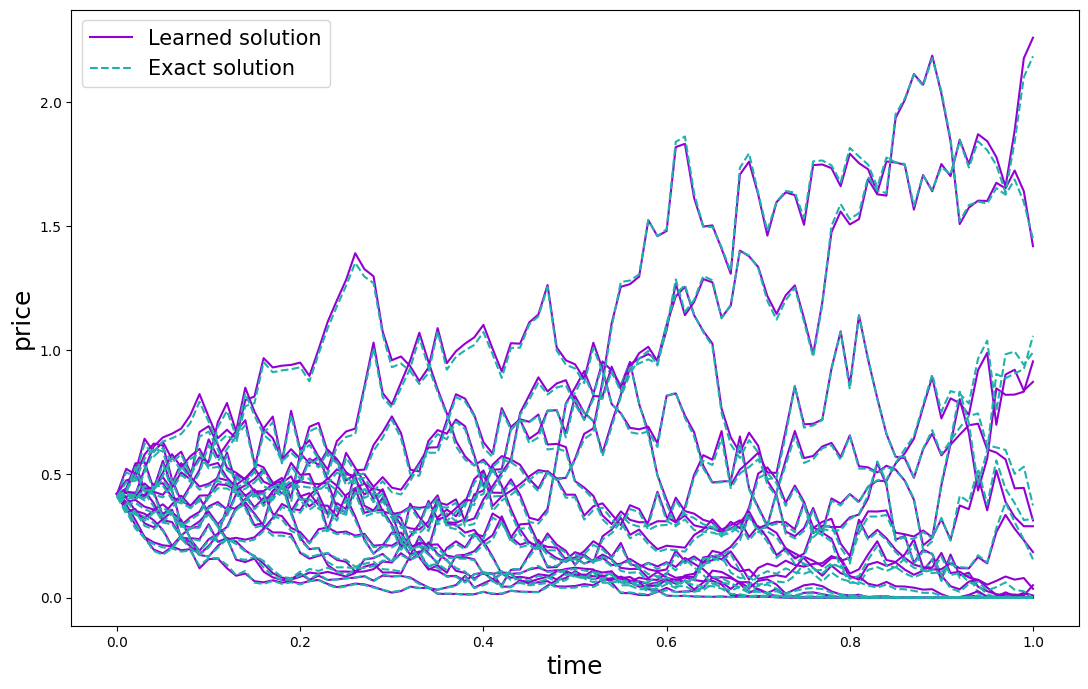

In [53]:
# config = {"s":10, "r":0.03, "sigma": 0.3, "kappa":1.01}
# config = {"s":10, "r":0.03, "sigma": 0.3}
config = {"s":10*[9.5], "r":[0.03], "rho": [0.1], "sigma": 10*[0.3], "kappa": [1.01]}
res = get_option_price_curve_d_10(mytrainer.model.module, 100, 16 ,config)
#  for data in datas: 
plot_mc_curves(res["t"], res["y_pred"], res["y_true"])